In [1]:
import qiskit
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import QuantumCircuit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import math
import numpy as np
from qiskit.circuit.library import HGate
from qiskit.circuit.library import TGate
from qiskit.circuit.library import SGate
from qiskit.circuit.library import SwapGate
from os import error
from qiskit import transpile
from qiskit.visualization import plot_distribution

In [2]:
def QRC(qc):
  gate_control = qc.qregs[0]
  target = qc.qregs[2]

  global x_gate_qrc
  global ccc_h_qrc
  global ccc_t_qrc
  global ccc_s_qrc
  global cccc_not_qrc

  qc.x(1)
  qc.x(2)

  c3h_gate = HGate().control(3)
  qc.append(c3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  t3h_gate = TGate().control(3)
  qc.append(t3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)
  qc.x(2)

  s3h_gate = SGate().control(3)
  qc.append(s3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  qc.mcx([gate_control[0],gate_control[1],gate_control[2],target[0]],target[1])

  x_gate_qrc = x_gate_qrc + 6
  ccc_h_qrc = ccc_h_qrc + 1
  ccc_t_qrc = ccc_t_qrc + 1
  ccc_s_qrc = ccc_s_qrc + 1
  cccc_not_qrc = cccc_not_qrc + 1

  qc.barrier()


In [3]:
def QRC_Gray_Code(qc):
  gate_control = qc.qregs[0]
  target = qc.qregs[2]

  global x_gate_qrc
  global ccc_h_qrc
  global ccc_t_qrc
  global ccc_s_qrc
  global cccc_not_qrc

  #00
  qc.mcx([gate_control[0],gate_control[1],gate_control[2],target[0]],target[1])

  qc.x(2)

  #01
  t3h_gate = TGate().control(3)
  qc.append(t3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  #11
  c3h_gate = HGate().control(3)
  qc.append(c3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(2)

  #10
  s3h_gate = SGate().control(3)
  qc.append(s3h_gate, [gate_control[0],gate_control[1],gate_control[2],target[0]])

  qc.x(1)

  #00

  x_gate_qrc = x_gate_qrc + 4
  ccc_h_qrc = ccc_h_qrc + 1
  ccc_t_qrc = ccc_t_qrc + 1
  ccc_s_qrc = ccc_s_qrc + 1
  cccc_not_qrc = cccc_not_qrc + 1

  qc.barrier()

In [4]:
def Gray_Code_List(n):
    result = []
    for i in range(2 ** n):
        gray = i ^ (i >> 1)
        result.append(format(gray, f'0{n}b'))
    result.append(result[0])
    return result

In [51]:
def Swap_Gate(qc):
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  global x_gate_qrc
  global cc_swap_on_n_qubits_qrc
  global swap_control_state

  for j in range(2 ** (len(swap_control) - 3)):
    for k in range(len(swap_control) - 3):
      if(j % (2 ** k) == 0):
        qc.x(swap_control[k + 3])
        x_gate_qrc = x_gate_qrc + 1
        swap_control_state[k + 3] ^= 1

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control)) if k not in (1, 2)]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j + 1]])
    cc_swap_on_n_qubits_qrc = cc_swap_on_n_qubits_qrc + 1

  qc.barrier()

In [50]:
def Swap_Gate_Gray_Code(qc):
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  global x_gate_qrc
  global cc_swap_on_n_qubits_qrc
  global gray_code
  global swap_control_state

  for j in range(len(gray_code)):
    for k in range(len(gray_code[j])):
      if(j == 0):
        break
      if(gray_code[j][k] != gray_code[j-1][k]):
        qc.x(swap_control[k + 3])
        x_gate_qrc = x_gate_qrc + 1
        swap_control_state[k + 3] ^= 1

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control)) if k not in (1, 2)]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j + 1]])
    cc_swap_on_n_qubits_qrc = cc_swap_on_n_qubits_qrc + 1

  qc.barrier()

In [49]:
def Reverse_Swap_Gate(qc):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  global x_gate_qrc
  global cc_swap_on_n1_qubits_qrc
  global swap_control_state

  for j in range(2 ** (len(swap_control) - 3)):
    for k in range(len(swap_control) - 3):
      if(j % (2 ** k) == 0):
        qc.x(swap_control[k + 3])
        x_gate_qrc = x_gate_qrc + 1
        swap_control_state[k + 3] ^= 1

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control)) if k not in (1, 2)] + [gate_control[0]]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j + 1]])
    cc_swap_on_n1_qubits_qrc = cc_swap_on_n1_qubits_qrc + 1

  qc.barrier()

In [48]:
def Reverse_Swap_Gate_Gray_Code(qc):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]
  target = qc.qregs[2]
  n = len(target)

  global x_gate_qrc
  global cc_swap_on_n1_qubits_qrc
  global swap_control_state

  for j in range(len(gray_code)):
    for k in range(len(gray_code[j])):
      if(j == 0):
        break
      if(gray_code[j][k] != gray_code[j-1][k]):
        qc.x(swap_control[k + 3])
        x_gate_qrc = x_gate_qrc + 1
        swap_control_state[k + 3] ^= 1

    if(j >= n - 1):
      continue

    controls = [swap_control[k] for k in range(len(swap_control)) if k not in (1, 2)] + [gate_control[0]]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[j + 1]])
    cc_swap_on_n1_qubits_qrc = cc_swap_on_n1_qubits_qrc + 1

  qc.barrier()

In [9]:
def Swap_Cnot_Target(qc):
    swap_control = qc.qregs[1]
    target = qc.qregs[2]

    global c_swap_qrc

    controls = [swap_control[1]]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[1]])
    c_swap_qrc = c_swap_qrc + 1

    qc.barrier()

In [10]:
def Reverse_Swap_Cnot_Target(qc):
    swap_control = qc.qregs[1]
    target = qc.qregs[2]

    global c_swap_qrc

    controls = [swap_control[2]]
    mc_swap = SwapGate().control(len(controls))
    qc.append(mc_swap, controls + [target[0], target[1]])
    c_swap_qrc = c_swap_qrc + 1

    qc.barrier()

In [37]:
def Apply_Gate(qc):

  global gate_control_state
  global swap_control_state
  global reconfigurable_cell_count
  reconfigurable_cell_count = reconfigurable_cell_count + 1
  
  print("QRC: " + str(reconfigurable_cell_count) + " Gate Control Qubits: " + str(gate_control_state) + " Swap Control Qubits: " + str(swap_control_state))

  Reverse_Swap_Cnot_Target(qc)
  #Swap_Gate(qc)
  Swap_Gate_Gray_Code(qc)
  Swap_Cnot_Target(qc)
  #QRC(qc)
  QRC_Gray_Code(qc)
  #Reverse_Swap_Gate(qc)
  Reverse_Swap_Gate_Gray_Code(qc)

['00', '01', '11', '10', '00']
qubits = 13
x_gate_qrc = 12
c_swap_qrc = 2
cc_swap_on_n_qubits_qrc = 4
cc_swap_on_n1_qubits_qrc = 4
ccc_h_qrc = 1
ccc_t_qrc = 1
ccc_s_qrc = 1
cccc_not_qrc = 1
reconfigurable_cell_count = 1


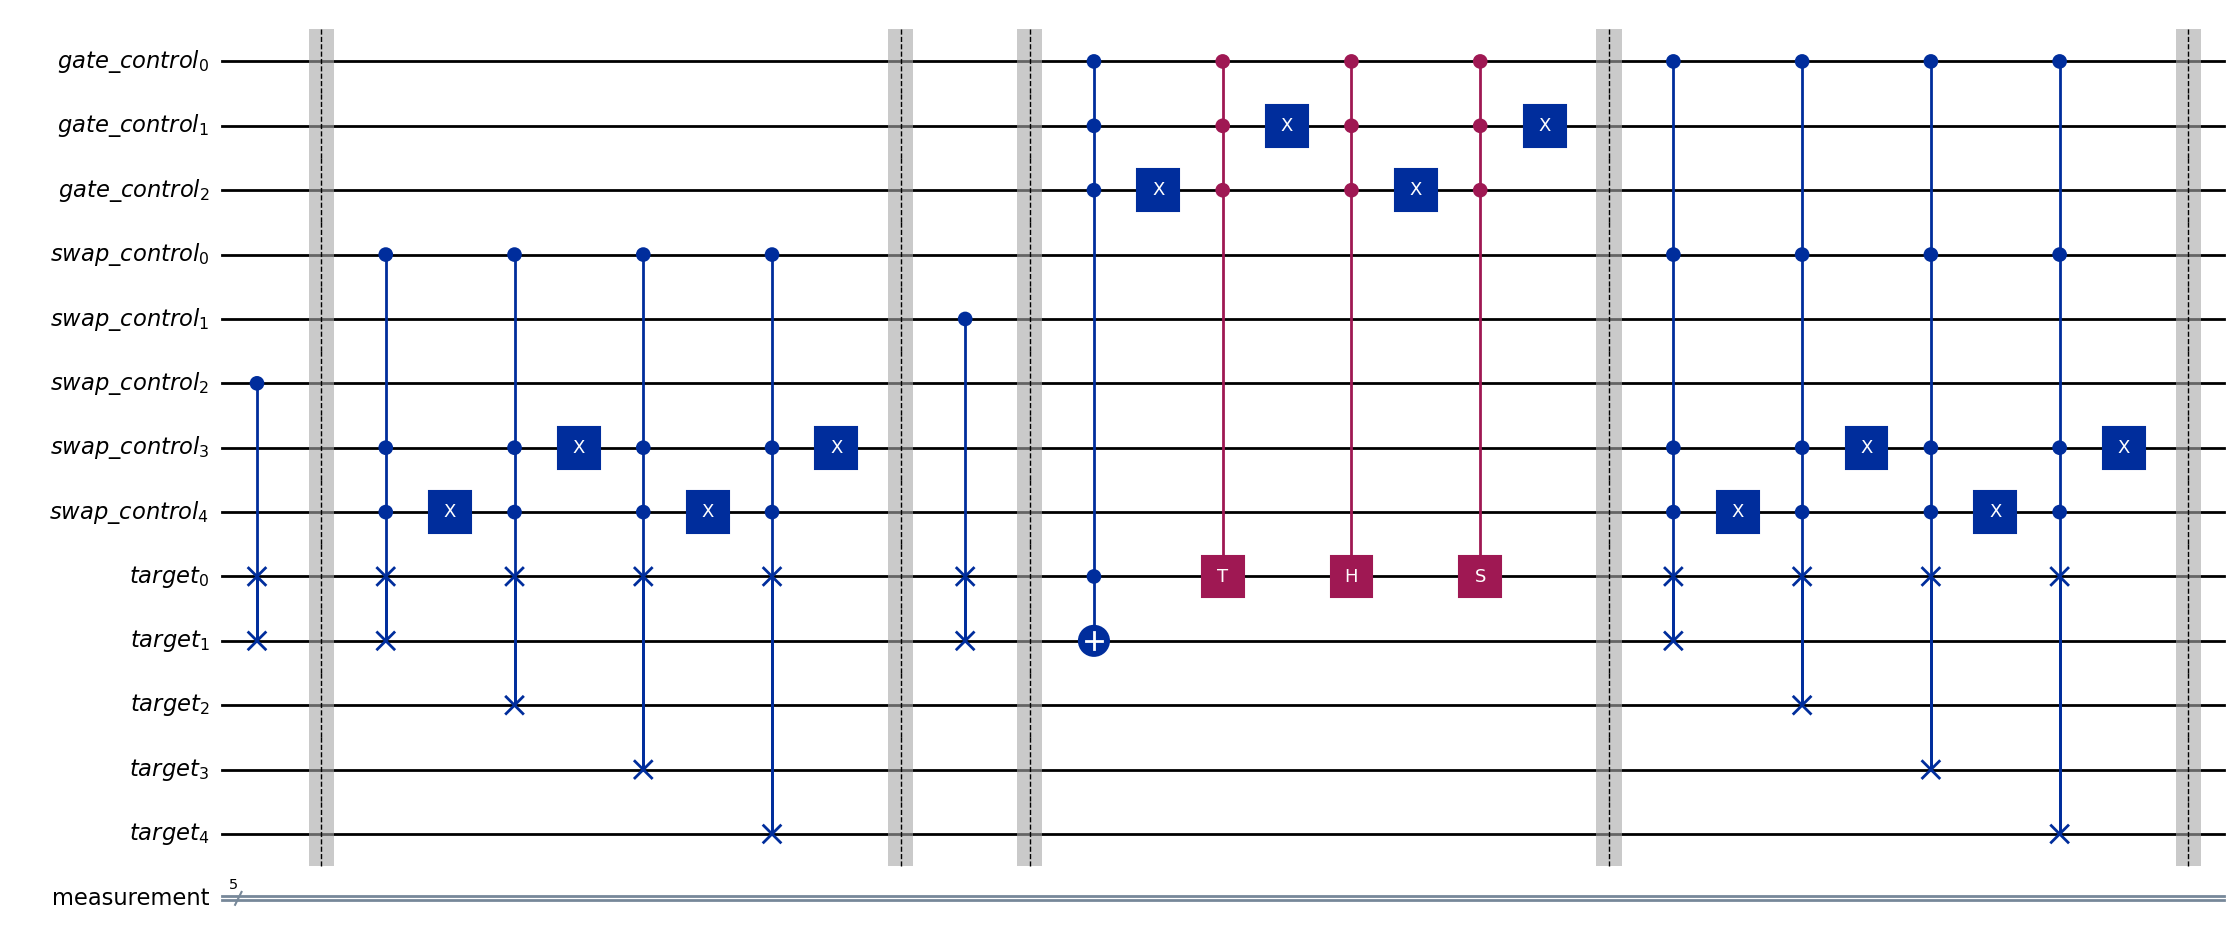

In [12]:
n = 5

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(3 + math.ceil(math.log2(n - 1)), "swap_control")
target = QuantumRegister(n, "target")

measurement = ClassicalRegister(n, "measurement")

x_gate_qrc = 0
c_swap_qrc = 0
cc_swap_on_n_qubits_qrc = 0
cc_swap_on_n1_qubits_qrc = 0
ccc_h_qrc = 0
ccc_t_qrc = 0
ccc_s_qrc = 0
cccc_not_qrc = 0
reconfigurable_cell_count = 0

gray_code = Gray_Code_List(math.ceil(math.log2(n - 1)))

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

Apply_Gate(qc)

print(gray_code)

print("qubits = " + str(3 + 3 + n + math.ceil(math.log2(n - 1))))
print("x_gate_qrc = " + str(x_gate_qrc))
print("c_swap_qrc = " + str(c_swap_qrc))
print("cc_swap_on_n_qubits_qrc = " + str(cc_swap_on_n_qubits_qrc))
print("cc_swap_on_n1_qubits_qrc = " + str(cc_swap_on_n1_qubits_qrc))
print("ccc_h_qrc = " + str(ccc_h_qrc))
print("ccc_t_qrc = " + str(ccc_t_qrc))
print("ccc_s_qrc = " + str(ccc_s_qrc))
print("cccc_not_qrc = " + str(cccc_not_qrc))
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

qc.draw(output="mpl", fold=-1)

In [52]:
def Modify_Swap_Control_Bits_Old(qc, target_qubit):
  swap_control = qc.qregs[1]

  global x_gate_qrc
  global swap_control_state

  if(target_qubit == 0):
    qc.x(swap_control[0])
    x_gate_qrc = x_gate_qrc + 1
    swap_control_state[0] ^= 1
    return

  number_of_bits = len(swap_control) - 3
  binary = format(target_qubit - 1, f'0{number_of_bits}b')

  bit_id = 2

  for bit in reversed(binary):
    bit_id = bit_id + 1
    if bit == '1':
      qc.x(swap_control[bit_id])
      x_gate_qrc = x_gate_qrc + 1
      swap_control_state[bit_id] ^= 1

In [53]:
def Modify_Swap_Control_Bits(qc, target_qubit):
  swap_control = qc.qregs[1]

  global x_gate_qrc
  global gray_code
  global swap_control_state

  if(target_qubit == 0):
    qc.x(swap_control[0])
    x_gate_qrc = x_gate_qrc + 1
    swap_control_state[0] ^= 1
    return

  binary = gray_code[target_qubit-1]

  bit_id = 2

  for bit in binary:
    bit_id = bit_id + 1
    if bit == '0':
      qc.x(swap_control[bit_id])
      x_gate_qrc = x_gate_qrc + 1
      swap_control_state[bit_id] ^= 1

In [54]:
def Modify_Swap_Control_Bits_Gray_Code(qc, target_qubit):
  swap_control = qc.qregs[1]

  global x_gate_qrc
  global gray_code
  global swap_control_state

  if(target_qubit == 0):
    qc.x(swap_control[0])
    x_gate_qrc = x_gate_qrc + 1
    swap_control_state[0] ^= 1
    return

  binary = gray_code[target_qubit-1]

  bit_id = 2

  for bit in binary:
    bit_id = bit_id + 1
    if bit == '0':
      qc.x(swap_control[bit_id])
      x_gate_qrc = x_gate_qrc + 1
      swap_control_state[bit_id] ^= 1

In [39]:
def NOP_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]

  global x_gate_qrc
  global gate_control_state

  #Apply X on gate qubits
  qc.x(gate_control[0])
  x_gate_qrc = x_gate_qrc + 1
  gate_control_state[0] ^= 1

  #Apply X on swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()
  #qc.x(swap_control[target_qubit])

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()
  #qc.x(swap_control[target_qubit])

  #Restore gate qubits
  qc.x(gate_control[0])
  x_gate_qrc = x_gate_qrc + 1
  gate_control_state[0] ^= 1

In [17]:
def H_Gate(qc, target_qubit):
  #Apply X on gate qubits
  #Nothing to do for H Gate

  #Apply X on swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  #Nothing to do for H Gate

In [40]:
def T_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]

  global x_gate_qrc
  global gate_control_state
  
  #Apply X on gate qubits
  qc.x(gate_control[1])
  x_gate_qrc = x_gate_qrc + 1
  gate_control_state[1] ^= 1

  #Apply X on swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[1])
  x_gate_qrc = x_gate_qrc + 1
  gate_control_state[1] ^= 1

In [41]:
def S_Gate(qc, target_qubit):
  gate_control = qc.qregs[0]

  global x_gate_qrc
  global gate_control_state

  #Apply X on gate qubits
  qc.x(gate_control[2])
  x_gate_qrc = x_gate_qrc + 1
  gate_control_state[2] ^= 1

  #Apply X on swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Apply Swap, QRC and Reverser-Swap
  Apply_Gate(qc)

  #Restore swap qubits
  Modify_Swap_Control_Bits(qc, target_qubit)
  qc.barrier()

  #Restore gate qubits
  qc.x(gate_control[2])
  x_gate_qrc = x_gate_qrc + 1
  gate_control_state[2] ^= 1

In [56]:
def CNOT_Gate(qc, control_qubit, target_qubit):
  gate_control = qc.qregs[0]
  swap_control = qc.qregs[1]

  global x_gate_qrc
  global gate_control_state
  global swap_control_state

  if(control_qubit == target_qubit):
    raise ValueError(f"Error: Control and target qubits of the CNOT gate must be different!")
  
  if(target_qubit != 1):
    #if the control qubit is on the first position, than after the swaps made on the target qubit it will be left
    #in the place of the target qubit and we need to adjust the value of the control qubit to know which qubit
    #needs to be swapped back to the first position
    if(control_qubit == 0):
      control_qubit = target_qubit

    #if the control qubit is on the second position, than after the swaps made on the target qubit it will be left
    #on the first position and we need to adjust the value of the control qubit to know which qubit needs to be
    #swapped back to the first position
    if(control_qubit == 1):
      control_qubit = 0
  
    qc.x(swap_control[1])
    x_gate_qrc = x_gate_qrc + 1
    swap_control_state[1] ^= 1

    NOP_Gate(qc, target_qubit)

    qc.x(swap_control[1])
    x_gate_qrc = x_gate_qrc + 1
    swap_control_state[1] ^= 1

  qc.x(gate_control[1])
  qc.x(gate_control[2])
  x_gate_qrc = x_gate_qrc + 2
  gate_control_state[1] ^= 1
  gate_control_state[2] ^= 1

  Modify_Swap_Control_Bits(qc, control_qubit)
  qc.barrier()

  Apply_Gate(qc)

  Modify_Swap_Control_Bits(qc, control_qubit)
  qc.barrier()

  qc.x(gate_control[1])
  qc.x(gate_control[2])
  x_gate_qrc = x_gate_qrc + 2
  gate_control_state[1] ^= 1
  gate_control_state[2] ^= 1

  if(target_qubit != 1):
    qc.x(swap_control[2])
    x_gate_qrc = x_gate_qrc + 1
    swap_control_state[2] ^= 1

    NOP_Gate(qc, target_qubit)

    qc.x(swap_control[2])
    x_gate_qrc = x_gate_qrc + 1
    swap_control_state[2] ^= 1


In [21]:
def Z_Gate(qc, target_qubit):
  S_Gate(qc, target_qubit)
  S_Gate(qc, target_qubit)

In [22]:
def X_Gate(qc, target_qubit):
  H_Gate(qc, target_qubit)
  Z_Gate(qc, target_qubit)
  H_Gate(qc, target_qubit)

QRC: 47 Gate Control Qubits: [1, 0, 0] Swap Control Qubits: [0, 0, 0, 1, 0]


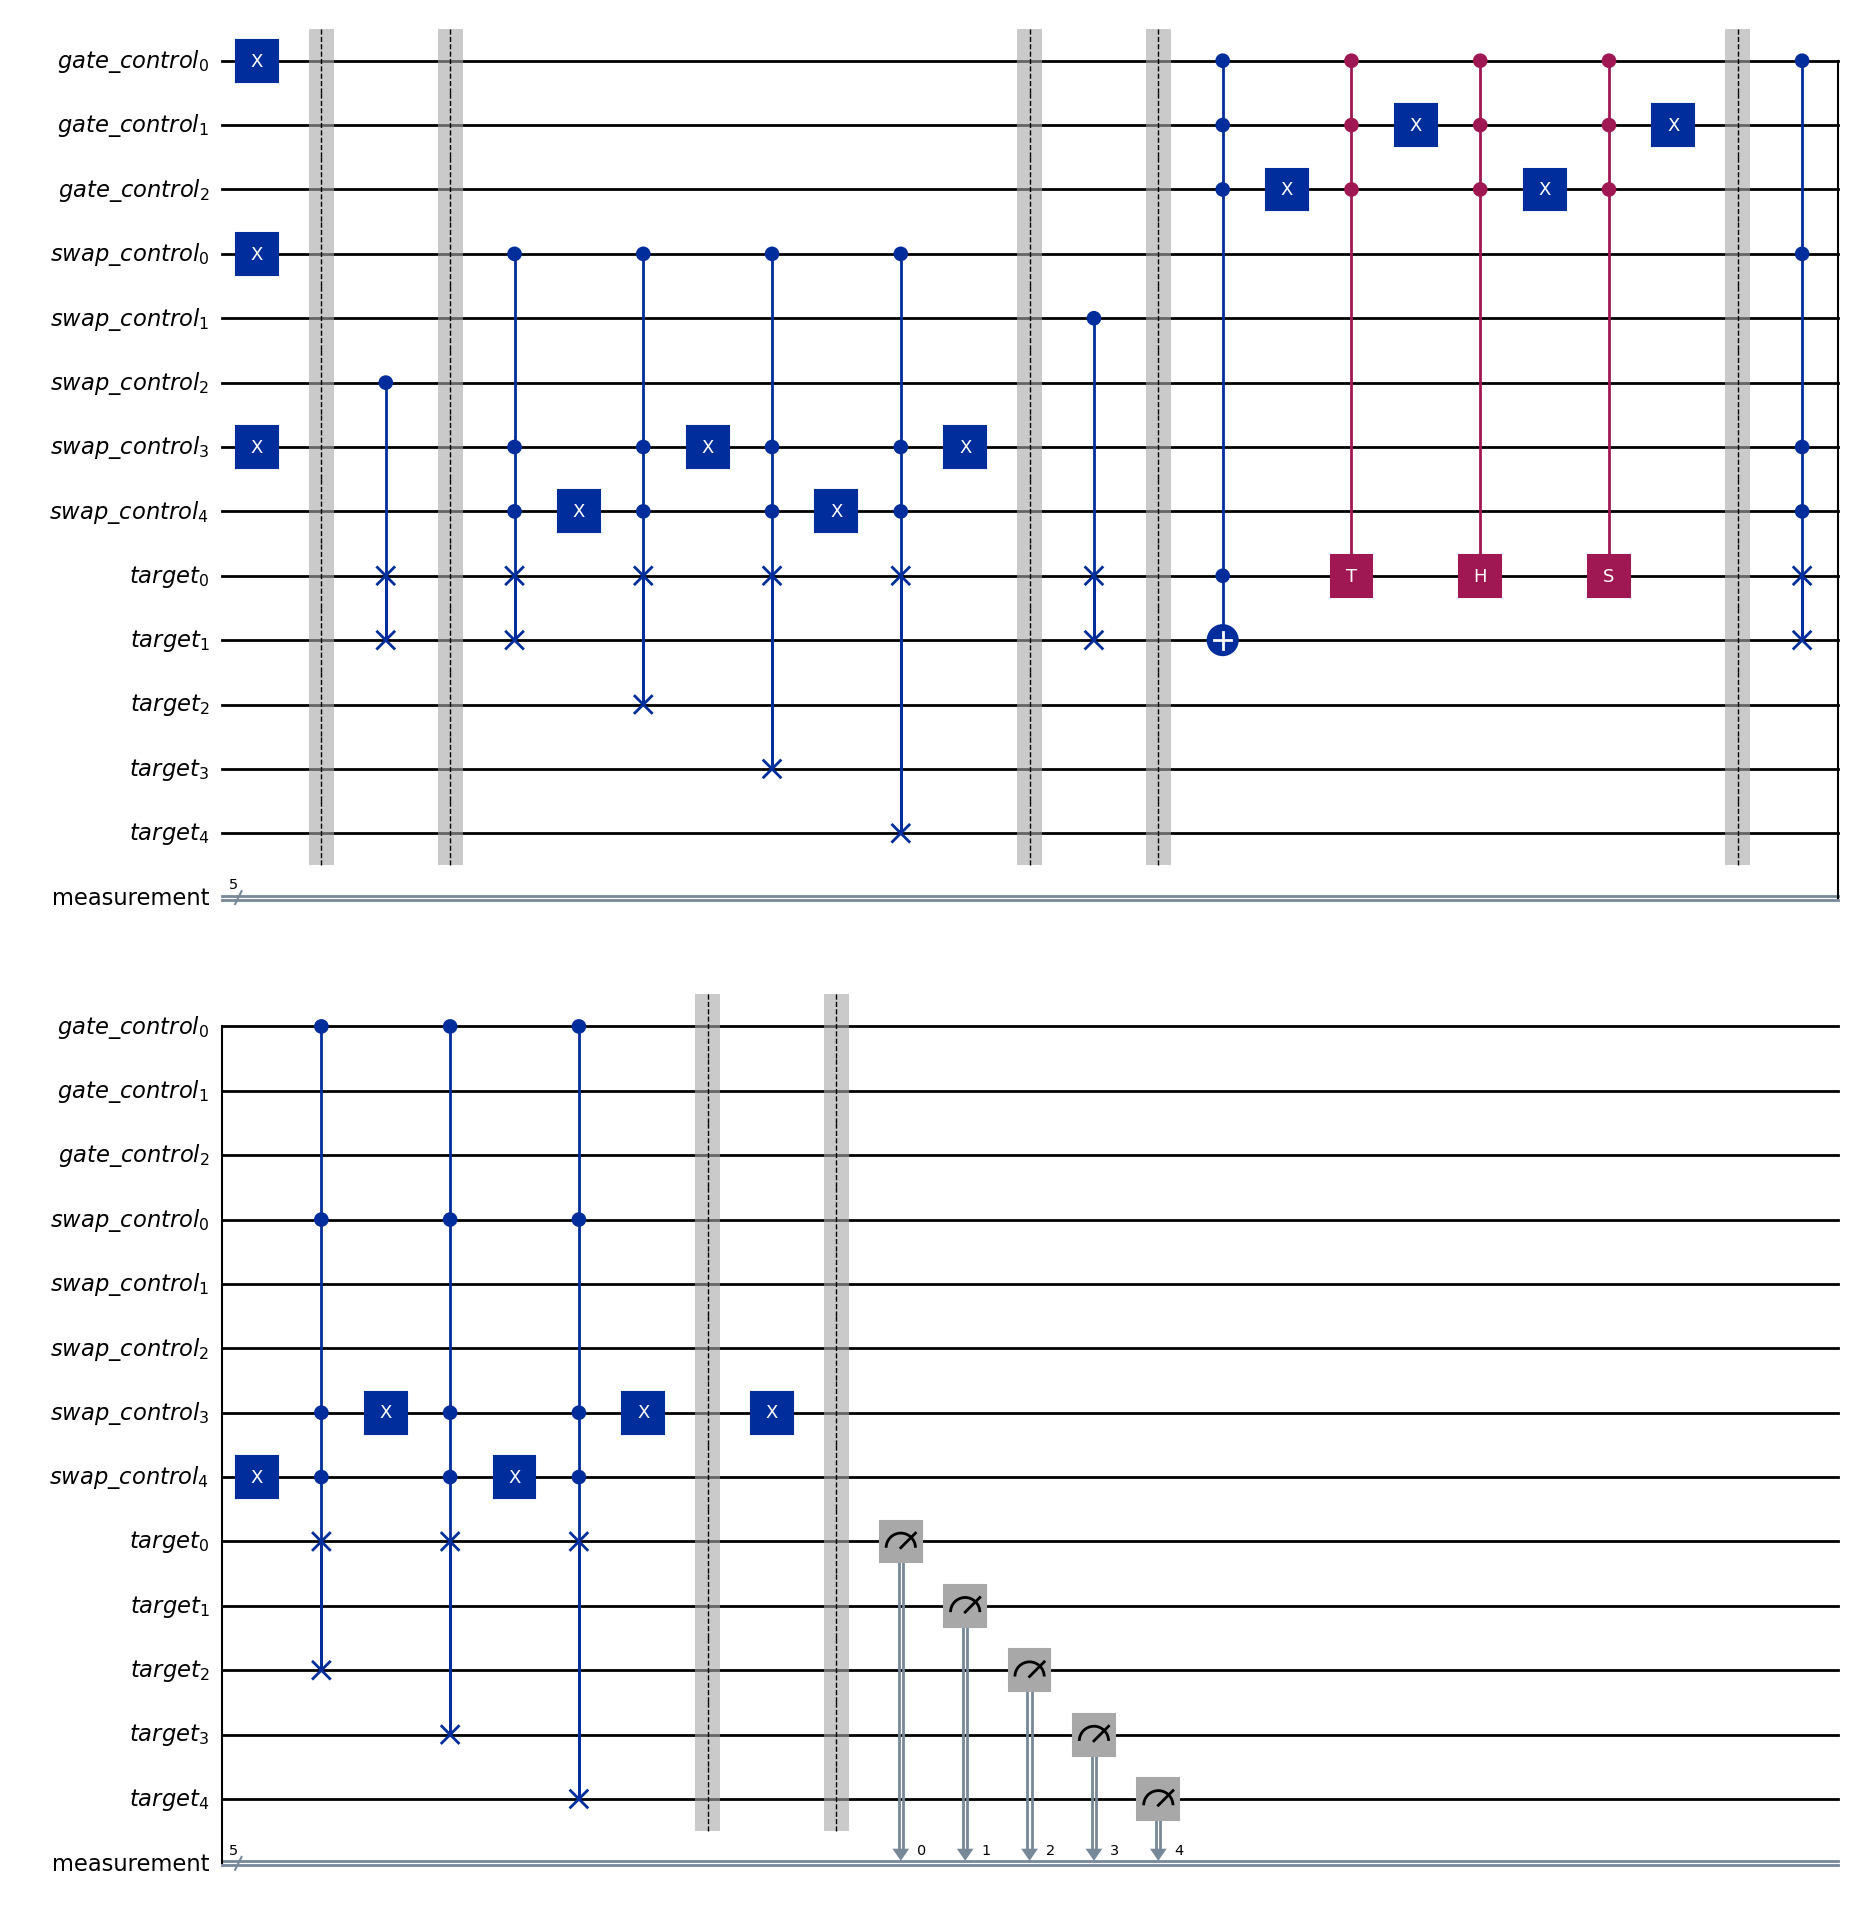

In [57]:
n = 5

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(3 + math.ceil(math.log2(n-1)), "swap_control")
target = QuantumRegister(n, "target")

measurement = ClassicalRegister(n, "measurement")

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

qc.x(gate_control[0])
gate_control_state[0] ^= 1
qc.x(swap_control[0])
swap_control_state[0] ^= 1

H_Gate(qc, 2)
#qc.x(target[3])
#CNOT_Gate(qc, 3, 2)

qc.measure(target, range(n))

qc.draw(output="mpl")

{'00100': 5063, '00000': 4937}


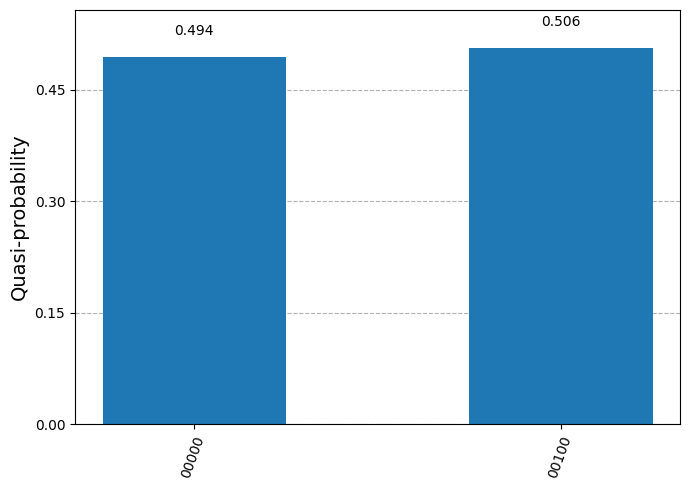

In [24]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
qc.measure(target, measurement)

qc_t = transpile(qc, sim, optimization_level=3)
result = sim.run(qc_t, shots=10_000).result()

counts = result.get_counts()
print(counts)

plot_distribution(counts)

In [25]:
def T_Dagger_Gate(qc, target_qubit):
  Z_Gate(qc, target_qubit)
  S_Gate(qc, target_qubit)
  T_Gate(qc, target_qubit)

In [26]:
def Toffoli_Gate(qc, control_qubit_1, control_qubit_2, target_qubit):
  T_Dagger_Gate(qc, control_qubit_1)
  T_Dagger_Gate(qc, control_qubit_2)
  H_Gate(qc, target_qubit)

  CNOT_Gate(qc, target_qubit, control_qubit_1)

  T_Gate(qc, control_qubit_1)
  CNOT_Gate(qc, control_qubit_2, target_qubit)

  CNOT_Gate(qc, control_qubit_2, control_qubit_1)
  T_Gate(qc, target_qubit)

  T_Dagger_Gate(qc, control_qubit_1)
  CNOT_Gate(qc, control_qubit_2, target_qubit)

  CNOT_Gate(qc, target_qubit, control_qubit_1)

  T_Gate(qc, control_qubit_1)
  T_Dagger_Gate(qc, target_qubit)

  CNOT_Gate(qc, control_qubit_2, control_qubit_1)
  H_Gate(qc, target_qubit)

In [27]:
def Toffoli_Gate_3(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[0], control_qubits[1], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[0], control_qubits[1], ancilla_qubit)

In [28]:
def Toffoli_Gate_4(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)

    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)

    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], ancilla_qubit)

In [29]:
def Toffoli_Gate_5(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])

    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

In [30]:
def Toffoli_Gate_6(qc, control_qubits, target_qubit, ancilla_qubit):
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

    Toffoli_Gate(qc, control_qubits[4], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[4], ancilla_qubit, target_qubit)
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])
    Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
    Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[4])

    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
    Toffoli_Gate(qc, control_qubits[3], control_qubits[4], ancilla_qubit)
    Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])

In [31]:
def Toffoli_Gate_7(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[5], control_qubits[6])

  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

In [32]:
def Toffoli_Gate_8(qc, control_qubits, target_qubit, ancilla_qubit):
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[0])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[6], ancilla_qubit, target_qubit)
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[1], control_qubits[3], control_qubits[0])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[5], control_qubits[2])
  Toffoli_Gate(qc, control_qubits[2], control_qubits[7], control_qubits[6])

  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[5], control_qubits[6], ancilla_qubit)
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])
  Toffoli_Gate(qc, control_qubits[0], control_qubits[2], control_qubits[3])
  Toffoli_Gate(qc, control_qubits[3], control_qubits[4], control_qubits[5])

In [33]:
def Reconfigurable_Oracle(qc, target_value):
  for i in range(len(target_value)):
    if(target_value[i] != '1'):
      X_Gate(qc, i)

  match len(target_value):
    case 3:
      Toffoli_Gate_3(qc, [0, 1, 2], 3, 4)
    case 4:
      Toffoli_Gate_4(qc, [0, 1, 2, 3], 4, 5)
    case 5:
      Toffoli_Gate_5(qc, [0, 1, 2, 3, 4], 5, 6)
    case 6:
      Toffoli_Gate_6(qc, [0, 1, 2, 3, 4, 5], 6, 7)
    case 7:
      Toffoli_Gate_7(qc, [0, 1, 2, 3, 4, 5, 6], 7, 8)
    case 8:
      Toffoli_Gate_8(qc, [0, 1, 2, 3, 4, 5, 6, 7], 8, 9)

  for i in range(len(target_value)):
    if(target_value[i] != '1'):
      X_Gate(qc, i)

In [34]:
def Reconfigurable_Diffuser(qc):
  n = len(qc.qregs[2]) - 2

  for i in range(n):
    H_Gate(qc, i)
    X_Gate(qc, i)

  H_Gate(qc, n-1)

  match n:
    case 2:
      CNOT_Gate(qc, 0, 1)
    case 3:
      Toffoli_Gate(qc, 0, 1, 2)
    case 4:
      Toffoli_Gate_3(qc, [0, 1, 2], 3, 5)
    case 5:
      Toffoli_Gate_4(qc, [0, 1, 2, 3], 4, 6)
    case 6:
      Toffoli_Gate_5(qc, [0, 1, 2, 3, 4], 5, 7)
    case 7:
      Toffoli_Gate_6(qc, [0, 1, 2, 3, 4, 5], 6, 8)
    case 8:
      Toffoli_Gate_7(qc, [0, 1, 2, 3, 4, 5, 6], 7, 9)

  H_Gate(qc, n-1)

  for i in range(n):
    X_Gate(qc, i)
    H_Gate(qc, i)

In [ ]:
#target_value = "110"
#target_value = "1101"
#target_value = "11010"
#target_value = "110100"
#target_value = "1101001"
target_value = "11010010"

n = len(target_value)

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(3 + math.ceil(math.log2(n+1)), "swap_control")
#swap_control = QuantumRegister(3 + math.ceil(math.log2(n)), "swap_control")
target = QuantumRegister(n+1+1, "target")
measurement = ClassicalRegister(n+1+1, "measurement")

x_gate_qrc = 0
c_swap_qrc = 0
cc_swap_on_n_qubits_qrc = 0
cc_swap_on_n1_qubits_qrc = 0
ccc_h_qrc = 0
ccc_t_qrc = 0
ccc_s_qrc = 0
cccc_not_qrc = 0
reconfigurable_cell_count = 0

gray_code = Gray_Code_List(math.ceil(math.log2(n+1)))

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

reconfigurable_cell_count = 0

qc.x(gate_control[0])
gate_control_state[0] ^= 1
qc.x(swap_control[0])
x_gate_qrc = x_gate_qrc + 2

#Start

X_Gate(qc, n)

for i in range(n+1):
  H_Gate(qc, i)

steps = math.sqrt(math.pow(2,n))
steps = round(math.pi/4 * steps)

print(steps)

for i in range(steps):
  Reconfigurable_Oracle(qc, target_value)
  Reconfigurable_Diffuser(qc)

#Reconfigurable_Oracle(qc, target_value)

#for i in range(len(target_value)):
#    if(target_value[i] != '1'):
#      X_Gate(qc, i)

#Toffoli_Gate(qc, 0, 1, 4)

H_Gate(qc, n)
X_Gate(qc, n)

#End

qc.x(gate_control[0])
qc.x(swap_control[0])
x_gate_qrc = x_gate_qrc + 2

qc.measure(target, range(n+1+1))

print("qubits = " + str(8 + math.ceil(math.log2(n+1) + n)))
print("x_gate_qrc = " + str(x_gate_qrc))
print("c_swap_qrc = " + str(c_swap_qrc))
print("cc_swap_on_" + str(1 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n_qubits_qrc))
print("cc_swap_on_" + str(2 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n1_qubits_qrc))
print("ccc_h_qrc = " + str(ccc_h_qrc))
print("ccc_t_qrc = " + str(ccc_t_qrc))
print("ccc_s_qrc = " + str(ccc_s_qrc))
print("cccc_not_qrc = " + str(cccc_not_qrc))
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

print(gray_code)

#qc.draw("mpl")

13


KeyboardInterrupt: 

{'00000': 4946, '00100': 5054}


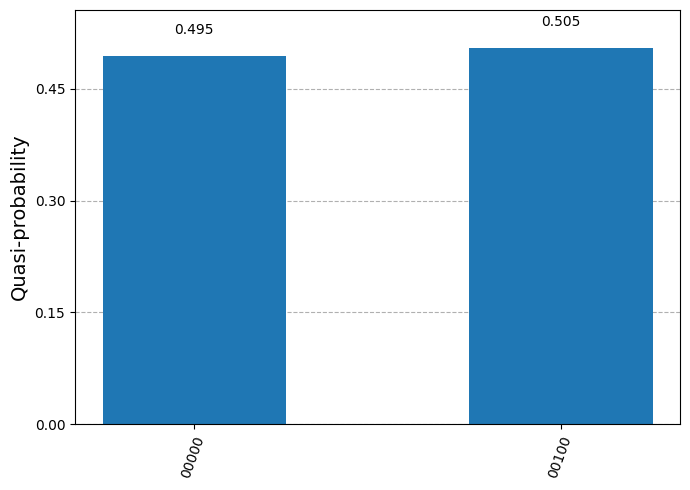

In [36]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
qc.measure(target, measurement)

qc_t = transpile(qc, sim, optimization_level=3)
result = sim.run(qc_t, shots=10_000).result()

counts = result.get_counts()
print(counts)

plot_distribution(counts)

In [58]:
#Half adder cell
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# q0=A, q1=B, q2=Sum, q3=Carry

n = 5

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(3 + math.ceil(math.log2(n-1)), "swap_control")
target = QuantumRegister(n, "target")
measurement = ClassicalRegister(2, "measurement")

x_gate_qrc = 0
c_swap_qrc = 0
cc_swap_on_n_qubits_qrc = 0
cc_swap_on_n1_qubits_qrc = 0
ccc_h_qrc = 0
ccc_t_qrc = 0
ccc_s_qrc = 0
cccc_not_qrc = 0
reconfigurable_cell_count = 0

gate_control_state = [0] * len(gate_control)
swap_control_state = [0] * len(swap_control)

print(gate_control_state)
print(swap_control_state)

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

qc.x(gate_control[0])
gate_control_state[0] ^= 1

qc.x(swap_control[0])
swap_control_state[0] ^= 1

# Set inputs A=1, B=1
qc.x(target[0])
qc.x(target[1])

# Half Adder
CNOT_Gate(qc, 0, 3)
CNOT_Gate(qc, 1, 3)
Toffoli_Gate(qc, 0, 1, 4)

qc.x(gate_control[0])
qc.x(swap_control[0])

# Measure outputs only
qc.measure([target[n-2], target[n-1]], measurement)
#qc.measure(target, measurement)
#qc.measure(2, 0)  # Sum
#qc.measure(3, 1)  # Carry

#qc.draw(output="mpl")

sim = AerSimulator()

compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

print(result.get_counts())
print("qubits = " + str(6 + n + math.ceil(math.log2(n-1))))
print("x_gate_qrc = " + str(x_gate_qrc))
print("c_swap_qrc = " + str(c_swap_qrc))
print("cc_swap_on_" + str(1 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n_qubits_qrc))
print("cc_swap_on_" + str(2 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n1_qubits_qrc))
print("ccc_h_qrc = " + str(ccc_h_qrc))
print("ccc_t_qrc = " + str(ccc_t_qrc))
print("ccc_s_qrc = " + str(ccc_s_qrc))
print("cccc_not_qrc = " + str(cccc_not_qrc))
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

[0, 0, 0]
[0, 0, 0, 0, 0]
QRC: 1 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 1, 0, 0, 0]
QRC: 2 Gate Control Qubits: [1, 1, 1] Swap Control Qubits: [1, 0, 0, 0, 0]
QRC: 3 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1, 0, 0]
QRC: 4 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 1, 0, 0, 0]
QRC: 5 Gate Control Qubits: [1, 1, 1] Swap Control Qubits: [0, 0, 0, 0, 0]
QRC: 6 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1, 0, 0]
QRC: 7 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [0, 0, 0, 0, 0]
QRC: 8 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [0, 0, 0, 0, 0]
QRC: 9 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [0, 0, 0, 0, 0]
QRC: 10 Gate Control Qubits: [1, 1, 0] Swap Control Qubits: [0, 0, 0, 0, 0]
QRC: 11 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [1, 0, 0, 1, 1]
QRC: 12 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [1, 0, 0, 1, 1]
QRC: 13 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [1, 0, 0, 1

In [59]:
#Full adder cell
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# q0=A, q1=B, q2=Sum, q3=Carry

n = 5

gate_control = QuantumRegister(3, "gate_control")
swap_control = QuantumRegister(3 + math.ceil(math.log2(n-1)), "swap_control")
target = QuantumRegister(n, "target")
measurement = ClassicalRegister(2, "measurement")

x_gate_qrc = 0
c_swap_qrc = 0
cc_swap_on_n_qubits_qrc = 0
cc_swap_on_n1_qubits_qrc = 0
ccc_h_qrc = 0
ccc_t_qrc = 0
ccc_s_qrc = 0
cccc_not_qrc = 0
reconfigurable_cell_count = 0

gate_control_state = [0] * len(gate_control)
swap_control_state = [0] * len(swap_control)

qc = QuantumCircuit(gate_control, swap_control, target, measurement)

qc.x(gate_control[0])
gate_control_state[0] ^= 1
qc.x(swap_control[0])
swap_control_state[0] ^= 1

# Set inputs A=1, B=1
qc.x(target[0])
qc.x(target[1])
qc.x(target[2])

# Sum
CNOT_Gate(qc, 0, 3)
CNOT_Gate(qc, 1, 3)
CNOT_Gate(qc, 2, 3)

#Carry
Toffoli_Gate(qc, 0, 1, 4)
Toffoli_Gate(qc, 0, 2, 4)
Toffoli_Gate(qc, 1, 2, 4)

qc.x(gate_control[0])
gate_control_state[0] ^= 1
qc.x(swap_control[0])
swap_control_state[0] ^= 1

# Measure outputs only
qc.measure([target[n-2], target[n-1]], measurement)
#qc.measure(target, measurement)
#qc.measure(2, 0)  # Sum
#qc.measure(3, 1)  # Carry

#qc.draw(output="mpl")

sim = AerSimulator()

compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

print(result.get_counts())
print("qubits = " + str(6 + n + math.ceil(math.log2(n-1))))
print("x_gate_qrc = " + str(x_gate_qrc))
print("c_swap_qrc = " + str(c_swap_qrc))
print("cc_swap_on_" + str(1 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n_qubits_qrc))
print("cc_swap_on_" + str(2 + math.ceil(math.log2(n+1))) + "_qubits_qrc = " + str(cc_swap_on_n1_qubits_qrc))
print("ccc_h_qrc = " + str(ccc_h_qrc))
print("ccc_t_qrc = " + str(ccc_t_qrc))
print("ccc_s_qrc = " + str(ccc_s_qrc))
print("cccc_not_qrc = " + str(cccc_not_qrc))
print("reconfigurable_cell_count = " + str(reconfigurable_cell_count))

QRC: 1 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 1, 0, 0, 0]
QRC: 2 Gate Control Qubits: [1, 1, 1] Swap Control Qubits: [1, 0, 0, 0, 0]
QRC: 3 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1, 0, 0]
QRC: 4 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 1, 0, 0, 0]
QRC: 5 Gate Control Qubits: [1, 1, 1] Swap Control Qubits: [0, 0, 0, 0, 0]
QRC: 6 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1, 0, 0]
QRC: 7 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 1, 0, 0, 0]
QRC: 8 Gate Control Qubits: [1, 1, 1] Swap Control Qubits: [1, 0, 0, 1, 0]
QRC: 9 Gate Control Qubits: [0, 0, 0] Swap Control Qubits: [1, 0, 1, 0, 0]
QRC: 10 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [0, 0, 0, 0, 0]
QRC: 11 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [0, 0, 0, 0, 0]
QRC: 12 Gate Control Qubits: [1, 0, 1] Swap Control Qubits: [0, 0, 0, 0, 0]
QRC: 13 Gate Control Qubits: [1, 1, 0] Swap Control Qubits: [0, 0, 0, 0, 0]
QRC: 14 Gate Control 